# BreadBean_Analysis
**Chaoda Jiang**

## 0) Prepare

In [1]:
"""
BreadBean — data load and standardization

Assumed repo layout:
  project_root/
    data/
      raw/
        BreadBeanData.parquet
      processed/
        BreadBeanData_Cleaned.parquet   # created/overwritten by this cell
    notebooks/
      BreadBean_Analysis.ipynb
"""

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", None)

# Resolve paths relative to this notebook (works when run from notebooks/)
CWD = Path.cwd()
project_root = CWD if (CWD / "data").exists() else CWD.parent
raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

processed_path = processed_dir / "BreadBeanData_Cleaned.parquet"
raw_path = raw_dir / "BreadBeanData.parquet"

# Load processed if present; otherwise fall back to raw
data_path = processed_path if processed_path.exists() else raw_path
if not data_path.exists():
    raise FileNotFoundError(
        "Dataset not found. Expected at least one of:\n"
        f" - {processed_path}\n"
        f" - {raw_path}"
    )

df = pd.read_parquet(data_path)
print(f"Loaded: {data_path}")
print("Shape:", df.shape)

# Optional type coercion (applied only if columns exist)
numeric_fields = [
    "POP_TOTAL", "PROFIT", "INCOME", "COMPETITOR_COUNT", "NONCOMPETITOR_COUNT",
    "OTHER_BUSINESS_COUNT", "AREA", "RENT_RATE", "CAPITAL",
    "AGE_A", "AGE_B", "AGE_C", "AGE_D", "AGE_E",
]
for col in numeric_fields:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

if "STORE_ID" in df.columns:
    df["STORE_ID"] = df["STORE_ID"].astype(str)

# Always persist a standardized/cleaned copy to processed/
df.to_parquet(processed_path, index=False)
print(f"Saved standardized data to: {processed_path}")


Loaded: /Users/simon/UCSD/2025fall/2025fall_MGTA453_BusinessAnalytics/Session8(Nov17)/case5/github_breadbean/breadbean-cafe-analysis#/data/raw/BreadBeanData.parquet
Shape: (70, 18)
Saved standardized data to: /Users/simon/UCSD/2025fall/2025fall_MGTA453_BusinessAnalytics/Session8(Nov17)/case5/github_breadbean/breadbean-cafe-analysis#/data/processed/BreadBeanData_Cleaned.parquet


## 1) Environment & Data

In [2]:
print("Preview:"); display(df.head())
print("\nMissing counts:"); print(df.isna().sum())

Preview:


,STORE_ID,PROFIT,CAPITAL,AREA,STAFF,POP_TOTAL,AGE_A,AGE_B,AGE_C,AGE_D,AGE_E,INCOME,COMPETITOR_COUNT,NONCOMPETITOR_COUNT,OTHER_BUSINESS_COUNT,RENT_RATE,COST_INDEX,CITY_NAME
0,1,28339.672620,861.0718,129.0,14.0,8.58,0.98,1.28,0.56,1.00,3.10,27.6,8.0,1.0,45.0,16.1,129,
1,2,-1.455001,630.3028,91.0,12.0,8.46,1.29,0.72,1.20,1.49,3.10,28.3,2.0,2.0,27.0,11.4,116,
2,3,68.932678,1074.4360,140.0,13.0,19.25,2.94,2.49,3.71,4.03,5.27,30.2,5.0,4.0,5.0,21.7,142,
3,4,202.073327,882.0064,184.0,7.0,20.92,3.57,4.93,4.42,4.30,2.96,27.6,2.0,1.0,7.0,11.8,138,
4,5,115.778511,930.6688,144.0,14.0,11.66,1.70,1.14,2.20,2.14,2.63,33.9,1.0,3.0,25.0,16.6,126,



Missing counts:
STORE_ID                 0
PROFIT                  10
CAPITAL                  0
AREA                     0
STAFF                   10
POP_TOTAL                0
AGE_A                    0
AGE_B                    0
AGE_C                    0
AGE_D                    0
AGE_E                    0
INCOME                   0
COMPETITOR_COUNT         0
NONCOMPETITOR_COUNT      0
OTHER_BUSINESS_COUNT     0
RENT_RATE                0
COST_INDEX               0
CITY_NAME                0
dtype: int64


## 2) Before you start

### 2.1 Histograms

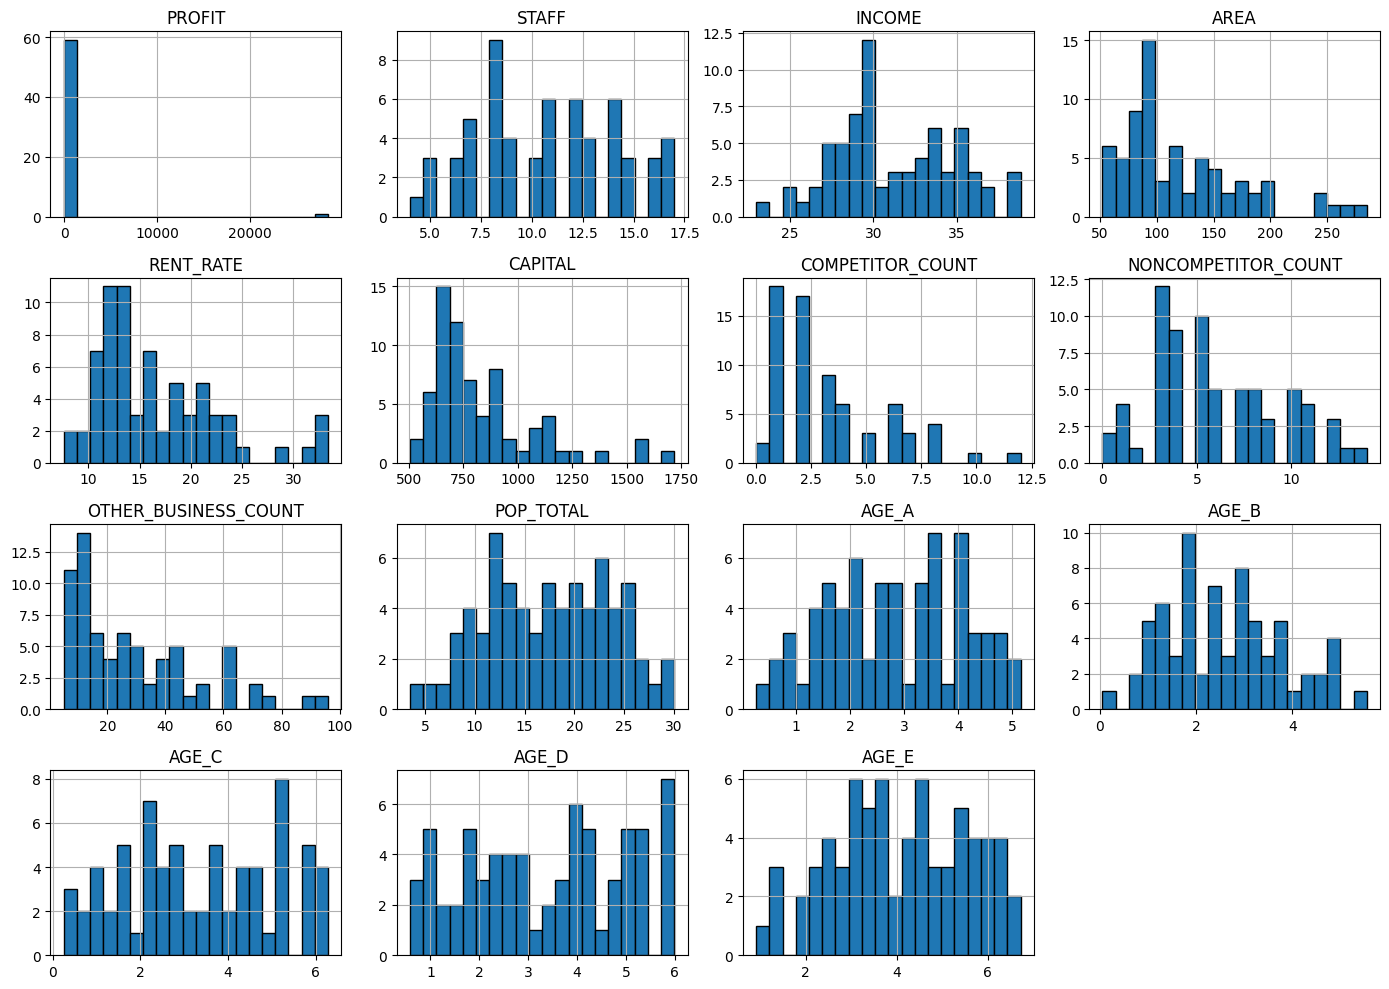

In [3]:
numeric_cols = [
    "PROFIT", "STAFF", "INCOME", "AREA", "RENT_RATE", "CAPITAL",
    "COMPETITOR_COUNT", "NONCOMPETITOR_COUNT", "OTHER_BUSINESS_COUNT",
    "POP_TOTAL", "AGE_A", "AGE_B", "AGE_C", "AGE_D", "AGE_E"
]
numeric_cols = [c for c in numeric_cols if c in df.columns]

df[numeric_cols].hist(bins=20, figsize=(14, 10), edgecolor="black")
plt.tight_layout()
plt.show()


### 2.2 Show rows with missing values (PROFIT/EMPL)

In [4]:
cols_of_interest = [c for c in ['PROFIT','EMPL'] if c in df.columns]
mask_missing = df[cols_of_interest].isna().any(axis=1) if cols_of_interest else pd.Series(False, index=df.index)
missing_rows = df.loc[mask_missing].copy()
print(f"Rows with missing in {cols_of_interest}: {len(missing_rows)}"); display(missing_rows)

Rows with missing in ['PROFIT']: 10


,STORE_ID,PROFIT,CAPITAL,AREA,STAFF,POP_TOTAL,AGE_A,AGE_B,AGE_C,AGE_D,AGE_E,INCOME,COMPETITOR_COUNT,NONCOMPETITOR_COUNT,OTHER_BUSINESS_COUNT,RENT_RATE,COST_INDEX,CITY_NAME
60,61,NaN,660.1396,54.0,NaN,6.71,0.60,2.57,0.43,0.690,1.44,38.4,4.0,5.0,18.0,21.7,131,Calais
61,62,NaN,733.0000,120.0,NaN,11.04,1.30,1.40,2.11,1.090,2.68,31.3,7.0,6.0,21.0,12.5,115,Montchanin
62,63,NaN,1050.3490,135.0,NaN,11.91,2.21,1.85,2.33,2.240,2.17,29.0,1.0,4.0,13.0,21.7,135,Aubusson
63,64,NaN,836.0000,245.0,NaN,11.35,3.40,3.00,2.57,1.200,1.35,37.0,5.0,8.0,62.0,12.5,136,Toulouse
64,65,NaN,783.6160,96.0,NaN,3.50,0.26,0.70,0.50,1.200,2.00,30.0,12.0,7.0,38.0,18.0,130,Torcy
65,66,NaN,924.8080,197.0,NaN,12.72,1.65,1.96,2.30,1.780,4.39,23.0,1.0,9.0,41.0,12.0,136,Marseilles-1
66,67,NaN,1089.5764,93.0,NaN,16.66,2.57,2.94,2.82,2.720,4.45,25.2,2.0,0.0,5.0,33.4,133,Marseilles-2
67,68,NaN,737.6620,169.0,NaN,9.41,0.78,1.94,0.88,1.080,3.45,30.1,4.0,4.0,11.0,9.0,126,Clermont
68,69,NaN,584.0000,149.0,NaN,19.02,2.50,2.68,4.60,4.567,3.00,28.6,4.0,5.0,26.0,13.4,128,Montpellier
69,70,NaN,681.0000,150.0,NaN,12.65,1.65,1.32,1.00,3.400,2.37,34.9,3.0,12.0,54.0,15.4,128,Dijon


### 2.3 Unified cleaning with 95th percentile (save new parquet)

In [5]:
"""
Winsorized variant for robustness checks.

Rules:
- For numeric columns, replace values above Q3 + 1.5*IQR with the column 95th percentile.
- For variables expected to be non-negative, replace non-positive values (<=0) with the 95th percentile.
- Missing values in numeric columns are also set to the 95th percentile.
Output:
  data/processed/BreadBeanFix_v95.parquet
"""

from pathlib import Path

# Ensure directories exist
processed_dir = processed_dir if "processed_dir" in globals() else (Path.cwd() / "data" / "processed")
processed_dir.mkdir(parents=True, exist_ok=True)

df_clean = df.copy()

# Numeric columns and variables that should be non-negative
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
positive_vars = {
    "PROFIT", "STAFF", "INCOME", "AREA", "RENT_RATE", "CAPITAL",
    "COMPETITOR_COUNT", "NONCOMPETITOR_COUNT", "OTHER_BUSINESS_COUNT",
    "POP_TOTAL", "AGE_A", "AGE_B", "AGE_C", "AGE_D", "AGE_E",
}
positive_vars = [c for c in positive_vars if c in df_clean.columns]

change_report = []
for col in num_cols:
    s = df_clean[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    p95 = s.quantile(0.95)

    # Flag: missing, non-positive (for positive_vars), or above upper fence
    mask = s.isna() | ((s <= 0) if col in positive_vars else False) | (s > upper_fence)
    nfix = int(mask.sum())
    if nfix > 0:
        df_clean.loc[mask, col] = p95
        change_report.append((col, nfix, float(p95), float(upper_fence)))

print("=== 95th Percentile Cleaning Report ===")
for col, n, p95, uf in change_report:
    print(f"{col}: replaced {n} values with p95={p95:.4f} (upper_fence={uf:.4f})")

print("\nRemaining missing after cleaning:")
print(df_clean.isna().sum())

# Save the winsorized variant under BreadBean naming in processed/
fix_out_path = processed_dir / "BreadBeanFix_v95.parquet"
df_clean.to_parquet(fix_out_path, index=False)
print("Saved p95-fixed dataset to:", fix_out_path)

# Optional: if a legacy file exists at project root, move/rename it for consistency
legacy_path = project_root / "CroqPainFix_v95.parquet"
if legacy_path.exists():
    legacy_path.replace(fix_out_path)
    print("Moved and renamed legacy file to:", fix_out_path)


=== 95th Percentile Cleaning Report ===
PROFIT: replaced 15 values with p95=295.3774 (upper_fence=420.4194)
CAPITAL: replaced 4 values with p95=1314.0783 (upper_fence=1288.7354)
AREA: replaced 4 values with p95=242.7500 (upper_fence=244.2500)
STAFF: replaced 10 values with p95=17.0000 (upper_fence=23.0000)
COMPETITOR_COUNT: replaced 3 values with p95=8.0000 (upper_fence=10.3750)
NONCOMPETITOR_COUNT: replaced 2 values with p95=12.0000 (upper_fence=15.5000)
OTHER_BUSINESS_COUNT: replaced 2 values with p95=70.5500 (upper_fence=87.8750)
RENT_RATE: replaced 3 values with p95=30.0100 (upper_fence=31.1625)

Remaining missing after cleaning:
STORE_ID                0
PROFIT                  0
CAPITAL                 0
AREA                    0
STAFF                   0
POP_TOTAL               0
AGE_A                   0
AGE_B                   0
AGE_C                   0
AGE_D                   0
AGE_E                   0
INCOME                  0
COMPETITOR_COUNT        0
NONCOMPETITOR_COUNT 

## Part (a): Visualization, Correlations, Per-capita vs Raw, VIF

### (a1) Scatterplots: POP_TOTAL vs AGE_A–AGE_E

Visualize the data: examine histograms and scatterplots.

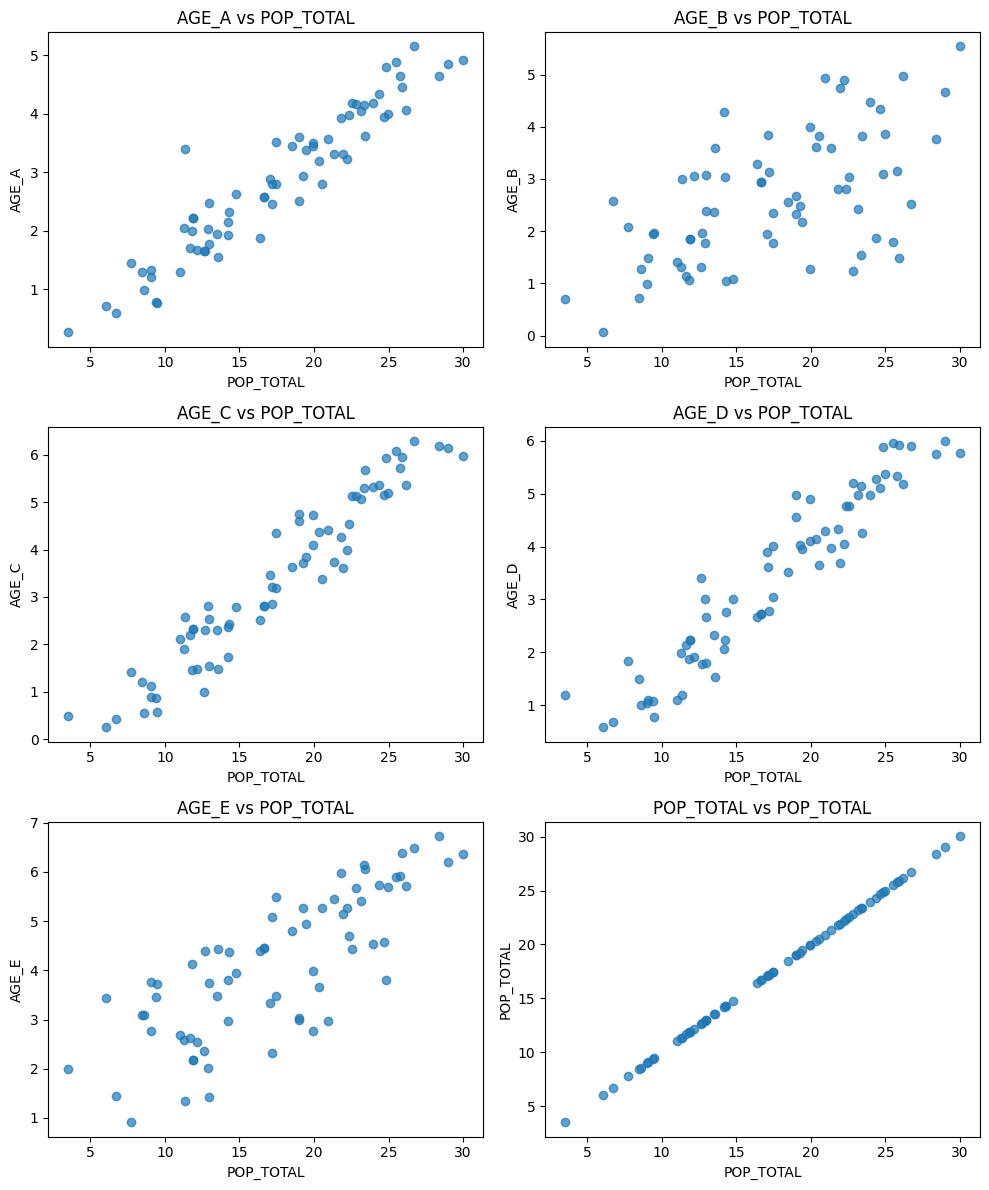

In [6]:
import matplotlib.pyplot as plt

age_cols = [c for c in ["AGE_A", "AGE_B", "AGE_C", "AGE_D", "AGE_E"] if c in df.columns]

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.ravel()

for i, col in enumerate(age_cols + (["POP_TOTAL"] if "POP_TOTAL" in df.columns else [])):
    if i >= len(axes):
        break
    axes[i].scatter(df["POP_TOTAL"], df[col], alpha=0.7)
    axes[i].set_xlabel("POP_TOTAL")
    axes[i].set_ylabel(col)
    axes[i].set_title(f"{col} vs POP_TOTAL")

plt.tight_layout()
plt.show()


### (a2) Correlations with PROFIT

Look at correlations between variables and try to identify sources of concern.

Apply a transformation to the variables `PROFIT`, `AGE_A`, `AGE_B`, `AGE_C`, `AGE_D`, `AGE_E`, `COMPETITOR_COUNT`, `NONCOMPETITOR_COUNT`, and `OTHER_BUSINESS_COUNT` where you normalize them by `POP_TOTAL`. You can apply this normalization by defining new variables such as `EARN_total` which is equal to `PROFIT` divided by `POP_TOTAL`.

In [7]:
cols = [
    "PROFIT", "POP_TOTAL", "INCOME", "COMPETITOR_COUNT",
    "NONCOMPETITOR_COUNT", "OTHER_BUSINESS_COUNT", "AREA",
    "RENT_RATE", "CAPITAL"
] + [c for c in ["AGE_A", "AGE_B", "AGE_C", "AGE_D", "AGE_E"] if c in df.columns]

cols = [c for c in cols if c in df.columns]

corr = df[cols].corr()
display(corr["PROFIT"].sort_values(ascending=False))


PROFIT                  1.000000
COMPETITOR_COUNT        0.264273
OTHER_BUSINESS_COUNT    0.099019
AREA                    0.037843
CAPITAL                 0.017857
RENT_RATE              -0.013165
AGE_E                  -0.104255
INCOME                 -0.136743
AGE_B                  -0.143079
NONCOMPETITOR_COUNT    -0.186888
POP_TOTAL              -0.198124
AGE_D                  -0.205899
AGE_A                  -0.211101
AGE_C                  -0.217961
Name: PROFIT, dtype: float64

### (a3) Compare models: raw vs per-capita

In [8]:
dfx = df.copy()  # create working copy

eps = 1e-6
for col in [
    "PROFIT", "COMPETITOR_COUNT", "NONCOMPETITOR_COUNT",
    "OTHER_BUSINESS_COUNT", "AREA", "CAPITAL",
    "AGE_A", "AGE_B", "AGE_C", "AGE_D", "AGE_E"
]:
    if col in dfx.columns and "POP_TOTAL" in dfx.columns:
        dfx[f"{col}_per1k"] = (dfx[col] / (dfx["POP_TOTAL"] + eps)).astype(float)

print("Per-capita columns:", [c for c in dfx.columns if c.endswith("_per1k")])


Per-capita columns: ['PROFIT_per1k', 'COMPETITOR_COUNT_per1k', 'NONCOMPETITOR_COUNT_per1k', 'OTHER_BUSINESS_COUNT_per1k', 'AREA_per1k', 'CAPITAL_per1k', 'AGE_A_per1k', 'AGE_B_per1k', 'AGE_C_per1k', 'AGE_D_per1k', 'AGE_E_per1k']


Evaluate correlations and regressions with both the transformed and un-transformed data.

In [9]:
import statsmodels.api as sm  # required for OLS

def fit_ols(frame, y, X_cols):
    X_cols = [c for c in X_cols if c in frame.columns]
    X = sm.add_constant(frame[X_cols])
    yv = frame[y]
    return sm.OLS(yv, X, missing="drop").fit()

raw_cols = [c for c in ["POP_TOTAL", "INCOME", "COMPETITOR_COUNT",
                        "OTHER_BUSINESS_COUNT", "AREA", "RENT_RATE", "CAPITAL"]
            if c in dfx.columns]

pc_cols  = [c for c in ["INCOME", "COMPETITOR_COUNT_per1k",
                        "OTHER_BUSINESS_COUNT_per1k", "AREA_per1k", "CAPITAL_per1k"]
            if c in dfx.columns]

m_raw = fit_ols(dfx, "PROFIT", raw_cols)
m_pc  = fit_ols(dfx, "PROFIT", pc_cols)

print("Raw model:")
print(m_raw.summary())
print("\nPer-capita model:")
print(m_pc.summary())

preferred = "per-capita" if m_pc.rsquared_adj > m_raw.rsquared_adj else "raw"
print(f"Preferred by adjusted R^2: {preferred} "
      f"(raw={m_raw.rsquared_adj:.3f}, per-capita={m_pc.rsquared_adj:.3f})")


Raw model:
                            OLS Regression Results                            
Dep. Variable:                 PROFIT   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1.093
Date:                Mon, 24 Nov 2025   Prob (F-statistic):              0.381
Time:                        00:05:46   Log-Likelihood:                -572.51
No. Observations:                  60   AIC:                             1161.
Df Residuals:                      52   BIC:                             1178.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                

**I prefer the per-capita (normalized) model.**

Although both models use the same predictors, the per-capita version controls for differences in market size by dividing each variable by POP_TOTAL, making it conceptually more meaningful.
Statistically, the adjusted R² of the per-capita model (0.140) is substantially higher than that of the raw model (0.011), suggesting that the normalized model explains more of the variation in PROFIT.
Moreover, the raw model’s coefficients (e.g., POP_TOTAL, AREA, RENT_RATE) are small and mostly insignificant, likely because PROFIT and several predictors are all driven by population scale.
Once normalized, this multicollinearity effect is reduced, and COMP_per1k becomes statistically significant, providing a clearer interpretation of competitive density effects.
Therefore, the per-capita model is preferred both theoretically (controls for size effects) and empirically (better fit and more interpretable results).

### (a4) VIF on per-capita set (if available)

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Per-capita predictors aligned with your per-capita model
X_cols = [c for c in [
    "INCOME",
    "COMPETITOR_COUNT_per1k",
    "OTHER_BUSINESS_COUNT_per1k",
    "AREA_per1k",
    "CAPITAL_per1k",
] if c in dfx.columns]

if X_cols:
    X = dfx[X_cols].copy()
    # guard against inf/NaN rows
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    if len(X) > 0:
        vif = pd.DataFrame({
            "variable": X_cols,
            "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        })
        display(vif)
    else:
        print("VIF skipped: no complete rows without NaN/Inf.")
else:
    print("VIF skipped: per-capita predictors not available.")


,variable,VIF
0,INCOME,4.303532
1,COMPETITOR_COUNT_per1k,3.237146
2,OTHER_BUSINESS_COUNT_per1k,3.507525
3,AREA_per1k,13.222521
4,CAPITAL_per1k,18.454528


### (a5) Regression validation checks (Section 6.6)


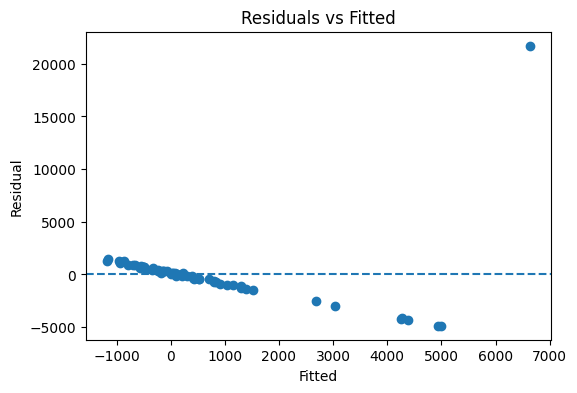

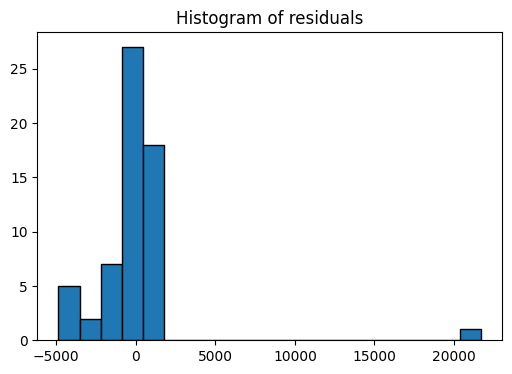

If residuals show skew or heteroskedasticity, consider log-transforming PROFIT and/or adding interaction terms (e.g., INCOME × COMPETITOR_COUNT).


In [11]:
### (a5) Regression validation checks (Section 6.6)

# Use the preferred model from (a3) — here we validate the per-capita model
resid = m_pc.resid
fitted = m_pc.fittedvalues

plt.figure(figsize=(6,4))
plt.scatter(fitted, resid)
plt.axhline(0, linestyle='--')
plt.xlabel('Fitted')
plt.ylabel('Residual')
plt.title('Residuals vs Fitted')
plt.show()

plt.figure(figsize=(6,4))
plt.hist(resid.dropna(), bins=20, edgecolor='black')
plt.title('Histogram of residuals')
plt.show()

print("If residuals show skew or heteroskedasticity, consider log-transforming PROFIT "
      "and/or adding interaction terms (e.g., INCOME × COMPETITOR_COUNT).")


In [12]:
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(resid)
print(f"Durbin–Watson: {dw:.3f} (~2 means no autocorrelation)")


Durbin–Watson: 1.144 (~2 means no autocorrelation)


## Part (b): Subset (first 50 existing stores) and Predictions

### (b1) Build subset

In [13]:
# (b1) Build subset — split between existing cafés and potential new sites

def is_non_empty_str(s):
    """Return True for non-empty, non-whitespace strings."""
    return s.astype(str).str.strip().ne("")

# Split existing vs. potential sites based on CITY_NAME availability
if "CITY_NAME" in df.columns:
    mask_potential = df["CITY_NAME"].notna() & is_non_empty_str(df["CITY_NAME"])
    df_existing = df.loc[~mask_potential].copy()
    df_potential = df.loc[mask_potential].copy()
else:
    df_existing = df.copy()
    df_potential = pd.DataFrame()

# Sort and select the first 50 existing cafés
if "STORE_ID" in df_existing.columns:
    df_existing = df_existing.sort_values("STORE_ID")
df_50 = df_existing.head(50).copy()
subset_idx = df_50.index

print(
    f"Existing cafés: {df_existing.shape} | "
    f"Potential sites: {df_potential.shape} | "
    f"First-50 subset: {df_50.shape}"
)


Existing cafés: (60, 18) | Potential sites: (10, 18) | First-50 subset: (50, 18)


### (b2) Diagnostics + robust fit + predict

In [14]:
# (b2) Diagnostics + robust fit + predict (uses df_50 from b1)
import numpy as np
import statsmodels.api as sm

subset_idx = df_50.index
print("subset_idx size:", len(subset_idx))  # expected ~50

# Per-capita vs. raw predictor sets (BreadBean naming)
cols_pc  = [c for c in [
    "INCOME",
    "COMPETITOR_COUNT_per1k",
    "OTHER_BUSINESS_COUNT_per1k",
    "AREA_per1k",
    "CAPITAL_per1k",
] if c in dfx.columns]

cols_raw = [c for c in [
    "POP_TOTAL", "INCOME", "COMPETITOR_COUNT",
    "OTHER_BUSINESS_COUNT", "AREA", "RENT_RATE", "CAPITAL"
] if c in dfx.columns]

# Diagnostics on missingness within the training subset
print("NaN counts in per-capita set (first-50 subset):")
if cols_pc:
    display(dfx.loc[subset_idx, cols_pc].isna().sum())
print("\nNaN counts in raw set (first-50 subset):")
if cols_raw:
    display(dfx.loc[subset_idx, cols_raw].isna().sum())

def try_fit_subset(X_cols):
    """Fit OLS on the first-50 subset with median imputation and finite-value filtering."""
    use_cols = ["PROFIT"] + X_cols
    dfx_exist = dfx.loc[subset_idx, use_cols].copy()

    # Median imputation for predictors only
    X_mat = dfx_exist[X_cols].astype(float)
    X_mat = X_mat.fillna(X_mat.median(numeric_only=True))

    # Assemble design matrix and target
    X = sm.add_constant(X_mat, has_constant="add")
    y = pd.to_numeric(dfx_exist["PROFIT"], errors="coerce")

    # Keep only rows with finite numeric values
    mask = (
        ~X.isna().any(axis=1)
        & ~y.isna()
        & np.isfinite(X.to_numpy()).all(axis=1)
        & np.isfinite(y.to_numpy())
    )
    X, y = X.loc[mask], y.loc[mask]
    print(f"[diag] after align & finite filter -> n={len(y)}, X shape={X.shape}")
    if len(y) == 0:
        raise ValueError("No valid observations for OLS—check subset or predictors.")
    return sm.OLS(y, X).fit()

# Prefer per-capita predictors if available
X_cols_use = cols_pc if cols_pc else cols_raw

m_50 = try_fit_subset(X_cols_use)
print(m_50.summary())

# ---- Predict for potential sites ----
if "CITY_NAME" in df.columns and not df_potential.empty:
    dfx_potential = dfx.loc[df_potential.index, X_cols_use].copy()

    # Impute using medians from the training subset
    medians_train = dfx.loc[subset_idx, X_cols_use].astype(float).median(numeric_only=True)
    dfx_potential = dfx_potential.astype(float).fillna(medians_train)

    X_new = sm.add_constant(dfx_potential, has_constant="add")
    df_potential["PROFIT_pred"] = m_50.predict(X_new)

    display(
        df_potential[["STORE_ID", "CITY_NAME", "PROFIT_pred"]]
        .sort_values("PROFIT_pred", ascending=False)
    )
else:
    print("No potential sites found for prediction.")


subset_idx size: 50
NaN counts in per-capita set (first-50 subset):


INCOME                        0
COMPETITOR_COUNT_per1k        0
OTHER_BUSINESS_COUNT_per1k    0
AREA_per1k                    0
CAPITAL_per1k                 0
dtype: int64


NaN counts in raw set (first-50 subset):


POP_TOTAL               0
INCOME                  0
COMPETITOR_COUNT        0
OTHER_BUSINESS_COUNT    0
AREA                    0
RENT_RATE               0
CAPITAL                 0
dtype: int64

[diag] after align & finite filter -> n=50, X shape=(50, 6)
                            OLS Regression Results                            
Dep. Variable:                 PROFIT   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     2.488
Date:                Mon, 24 Nov 2025   Prob (F-statistic):             0.0455
Time:                        00:05:47   Log-Likelihood:                -478.79
No. Observations:                  50   AIC:                             969.6
Df Residuals:                      44   BIC:                             981.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

,STORE_ID,CITY_NAME,PROFIT_pred
64,65,Torcy,26536.246724
61,62,Montchanin,3978.816838
60,61,Calais,3030.341510
67,68,Clermont,2704.798242
63,64,Toulouse,2097.334381
68,69,Montpellier,793.889764
65,66,Marseilles-1,724.865408
66,67,Marseilles-2,606.654681
69,70,Dijon,494.568458
62,63,Aubusson,138.729864


In [15]:
print("subset_idx size:", len(subset_idx))
print("dfx.loc[subset_idx].shape:", dfx.loc[subset_idx].shape)


subset_idx size: 50
dfx.loc[subset_idx].shape: (50, 29)


## Part (c): Validation & Diagnostics

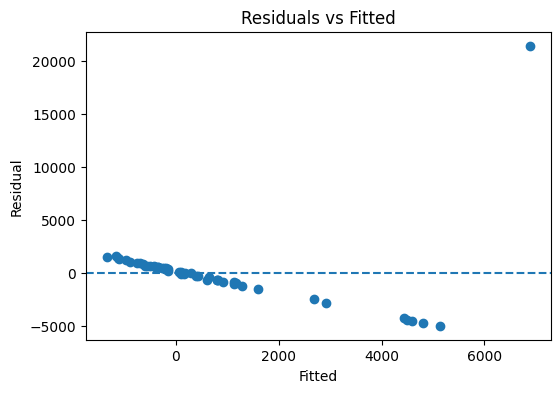

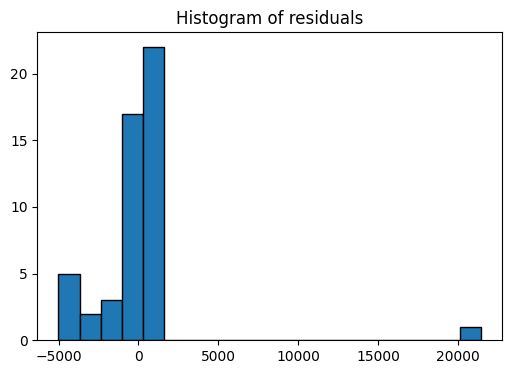

If residuals show skew or heteroskedasticity, consider log-transforming PROFIT and/or adding interaction terms (e.g., INCOME × COMPETITOR_COUNT).


In [16]:
resid = m_50.resid; fitted = m_50.fittedvalues
plt.figure(figsize=(6,4)); plt.scatter(fitted, resid); plt.axhline(0, linestyle='--')
plt.xlabel('Fitted'); plt.ylabel('Residual'); plt.title('Residuals vs Fitted'); plt.show()
plt.figure(figsize=(6,4)); plt.hist(resid.dropna(), bins=20, edgecolor='black'); plt.title('Histogram of residuals'); plt.show()
print("If residuals show skew or heteroskedasticity, consider log-transforming PROFIT and/or adding interaction terms (e.g., INCOME × COMPETITOR_COUNT).")

In [17]:
# 1) Standardized coefficients (beta)
X_std = sm.add_constant(
    (dfx.loc[df_50.index, X_cols_use] - dfx.loc[df_50.index, X_cols_use].mean())
    / dfx.loc[df_50.index, X_cols_use].std(ddof=0)
)
y_std = (
    (dfx.loc[df_50.index, "PROFIT"] - dfx.loc[df_50.index, "PROFIT"].mean())
    / dfx.loc[df_50.index, "PROFIT"].std(ddof=0)
)
m_std = sm.OLS(y_std, X_std, missing="drop").fit()
betas = m_std.params.drop("const").sort_values(key=lambda s: s.abs(), ascending=False)
print("\nStandardized coefficients (|beta| desc):")
display(betas)

# 2) VIF on the final X
X_vif = sm.add_constant(dfx.loc[df_50.index, X_cols_use].astype(float))
vif_df = pd.DataFrame({
    "variable": ["const"] + X_cols_use,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print("\nVIF (final model):")
display(vif_df)

# 3) Durbin–Watson (autocorrelation indicator)
dw = durbin_watson(m_50.resid.dropna().values)
print(f"\nDurbin–Watson: {dw:.3f}  (~2 indicates low autocorrelation)")

# 4) Cook’s distance (influence points)
influence = m_50.get_influence()
cooks = influence.cooks_distance[0]
influ_df = (
    pd.DataFrame({
        "STORE_ID": df_50["STORE_ID"].values,
        "CookD": cooks
    }, index=df_50.index)
    .sort_values("CookD", ascending=False)
)
print("\nTop potential high-influence points (Cook’s D):")
display(influ_df.head(10))



Standardized coefficients (|beta| desc):


COMPETITOR_COUNT_per1k        0.422921
INCOME                       -0.090491
CAPITAL_per1k                 0.040387
AREA_per1k                    0.023755
OTHER_BUSINESS_COUNT_per1k   -0.003301
dtype: float64


VIF (final model):


,variable,VIF
0,const,100.199625
1,INCOME,1.090727
2,COMPETITOR_COUNT_per1k,1.712507
3,OTHER_BUSINESS_COUNT_per1k,1.581477
4,AREA_per1k,6.843635
5,CAPITAL_per1k,6.658837



Durbin–Watson: 1.232  (~2 indicates low autocorrelation)

Top potential high-influence points (Cook’s D):


,STORE_ID,CookD
0,1,2.347178
23,24,0.571113
21,22,0.270814
18,19,0.047933
22,23,0.045526
24,25,0.042503
37,38,0.033405
51,52,0.021398
13,14,0.016017
9,10,0.007912
